# LeRobot Data Inspector

LeRobot dataset 폴더 경로를 넣으면 `data/`와 `meta/episodes/`를 읽어서 PCA 시각화와 episode 필터링을 할 수 있는 노트북입니다.

시각화 셀에서는 아래 두 방식 중 하나를 고를 수 있습니다.
- `score`: episode 요약 feature의 robust z-score 기반
- `frame_cluster`: 모든 frame의 `action`을 PCA 2D로 만든 뒤, 가장 큰 군집에서 멀리 벗어난 frame이 하나라도 있는 episode를 후보로 선택


In [23]:
%matplotlib inline
import shutil
import sys
from collections import deque
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lerobot.datasets.lerobot_dataset import LeRobotDatasetMetadata

REPO_ROOT = Path('/home/uon/ochansol/lerobot')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from chansol.data_editor.delete_episodes import (
    backup_file,
    dataframe_to_parquet,
    load_all_episode_rows,
    prune_empty_dirs,
    rewrite_data_files,
    rewrite_episode_metadata,
    rewrite_info,
    rewrite_tasks,
)
from lerobot.datasets.utils import (
    DEFAULT_EPISODES_PATH,
    DEFAULT_TASKS_PATH,
    INFO_PATH,
    STATS_PATH,
    load_info,
    write_stats,
)

DATASET_ROOT = Path('/nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_random_light')
REPO_ID = 'user1/repo1'
STATE_KEY = 'observation.state'
ACTION_KEY = 'action'
MAX_STATE_DIMS = None
MAX_ACTION_DIMS = None
MAX_STEP_POINTS = 30000
TOP_K_OUTLIERS = 50
RANDOM_SEED = 42

# 'score' or 'frame_cluster'
OUTLIER_METHOD = 'frame_cluster'
OUTLIER_PERCENTILE = 97.5
MAIN_CLUSTER_BINS = 140
CLUSTER_DENSITY_PERCENTILE = 70
SMOOTHING_PASSES = 2


def load_all_data_rows(dataset_root: Path) -> pd.DataFrame:
    files = sorted((dataset_root / 'data').glob('chunk-*/file-*.parquet'))
    if not files:
        raise FileNotFoundError(f'No data parquet files found in {dataset_root / "data"}')
    return pd.concat((pd.read_parquet(path) for path in files), ignore_index=True)


def pca_2d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x_centered = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(x_centered, full_matrices=False)
    return x_centered @ vt[:2].T


def robust_zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    med = np.median(x, axis=0, keepdims=True)
    mad = np.median(np.abs(x - med), axis=0, keepdims=True)
    mad = np.where(mad < 1e-9, 1.0, mad)
    return 0.6745 * (x - med) / mad


def as_1d_float_array(value) -> np.ndarray:
    return np.asarray(value, dtype=np.float64).reshape(-1)


def get_feature_names(dataset_root: Path, repo_id: str, key: str) -> list[str]:
    metadata = LeRobotDatasetMetadata(repo_id=repo_id, root=dataset_root)
    names = metadata.features[key].get('names')
    if names is None:
        dim = len(as_1d_float_array(metadata.stats[key]['mean']))
        prefix = key.split('.')[-1]
        return [f'{prefix}_{i}' for i in range(dim)]
    return list(names)


def build_episode_feature_matrix(episodes_df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    feature_rows = []
    episode_indices = []
    for _, row in episodes_df.sort_values('episode_index').iterrows():
        feature = np.concatenate([
            as_1d_float_array(row[f'stats/{STATE_KEY}/mean']),
            as_1d_float_array(row[f'stats/{STATE_KEY}/std']),
            as_1d_float_array(row[f'stats/{STATE_KEY}/min']),
            as_1d_float_array(row[f'stats/{STATE_KEY}/max']),
            as_1d_float_array(row[f'stats/{ACTION_KEY}/mean']),
            as_1d_float_array(row[f'stats/{ACTION_KEY}/std']),
            as_1d_float_array(row[f'stats/{ACTION_KEY}/min']),
            as_1d_float_array(row[f'stats/{ACTION_KEY}/max']),
            np.array([float(row['length'])], dtype=np.float64),
        ])
        feature_rows.append(feature)
        episode_indices.append(int(row['episode_index']))
    return np.asarray(feature_rows, dtype=np.float64), np.asarray(episode_indices, dtype=np.int64)


def smooth_histogram2d(hist: np.ndarray, passes: int) -> np.ndarray:
    smoothed = hist.astype(np.float64, copy=True)
    for _ in range(passes):
        padded = np.pad(smoothed, 1, mode='edge')
        smoothed = (
            padded[:-2, :-2] + padded[:-2, 1:-1] + padded[:-2, 2:] +
            padded[1:-1, :-2] + padded[1:-1, 1:-1] + padded[1:-1, 2:] +
            padded[2:, :-2] + padded[2:, 1:-1] + padded[2:, 2:]
        ) / 9.0
    return smoothed


def connected_component_from_seed(mask: np.ndarray, seed: tuple[int, int]) -> np.ndarray:
    visited = np.zeros_like(mask, dtype=bool)
    if not mask[seed]:
        return visited

    queue = deque([seed])
    visited[seed] = True
    height, width = mask.shape

    while queue:
        row, col = queue.popleft()
        for d_row in (-1, 0, 1):
            for d_col in (-1, 0, 1):
                if d_row == 0 and d_col == 0:
                    continue
                n_row = row + d_row
                n_col = col + d_col
                if n_row < 0 or n_row >= height or n_col < 0 or n_col >= width:
                    continue
                if not mask[n_row, n_col] or visited[n_row, n_col]:
                    continue
                visited[n_row, n_col] = True
                queue.append((n_row, n_col))
    return visited


def bin_points_2d(points_2d: np.ndarray, xedges: np.ndarray, yedges: np.ndarray) -> np.ndarray:
    x_idx = np.searchsorted(xedges, points_2d[:, 0], side='right') - 1
    y_idx = np.searchsorted(yedges, points_2d[:, 1], side='right') - 1
    x_idx = np.clip(x_idx, 0, len(xedges) - 2)
    y_idx = np.clip(y_idx, 0, len(yedges) - 2)
    return np.stack([x_idx, y_idx], axis=1)


def compute_main_cluster_component(
    points_2d: np.ndarray,
    bins: int,
    density_percentile: float,
    smoothing_passes: int,
) -> dict:
    hist, xedges, yedges = np.histogram2d(points_2d[:, 0], points_2d[:, 1], bins=bins)
    smoothed = smooth_histogram2d(hist, passes=smoothing_passes)
    positive = smoothed[smoothed > 0]
    if len(positive) == 0:
        raise ValueError('Could not build a non-empty density histogram.')

    density_threshold = np.percentile(positive, density_percentile)
    dense_mask = smoothed >= density_threshold
    peak_idx = np.unravel_index(np.argmax(smoothed), smoothed.shape)
    main_component = connected_component_from_seed(dense_mask, peak_idx)

    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    peak_center = np.array([xcenters[peak_idx[0]], ycenters[peak_idx[1]]], dtype=np.float64)

    point_bins = bin_points_2d(points_2d, xedges, yedges)
    point_in_component = main_component[point_bins[:, 0], point_bins[:, 1]]

    component_bin_indices = np.argwhere(main_component)
    component_centers = np.column_stack([
        xcenters[component_bin_indices[:, 0]],
        ycenters[component_bin_indices[:, 1]],
    ])

    unique_bins, inverse = np.unique(point_bins, axis=0, return_inverse=True)
    unique_bin_centers = np.column_stack([
        xcenters[unique_bins[:, 0]],
        ycenters[unique_bins[:, 1]],
    ])
    unique_bin_inside = main_component[unique_bins[:, 0], unique_bins[:, 1]]
    unique_bin_distance = np.zeros(len(unique_bins), dtype=np.float64)

    outside_idx = np.where(~unique_bin_inside)[0]
    if len(outside_idx) > 0:
        for idx in outside_idx:
            center = unique_bin_centers[idx]
            unique_bin_distance[idx] = np.linalg.norm(component_centers - center[None, :], axis=1).min()

    point_distance_to_component = unique_bin_distance[inverse]

    return {
        'hist': hist,
        'smoothed': smoothed,
        'xedges': xedges,
        'yedges': yedges,
        'xcenters': xcenters,
        'ycenters': ycenters,
        'density_threshold': density_threshold,
        'peak_idx': peak_idx,
        'peak_center': peak_center,
        'dense_mask': dense_mask,
        'main_component': main_component,
        'point_bins': point_bins,
        'point_in_component': point_in_component,
        'point_distance_to_component': point_distance_to_component,
    }


def select_outliers_from_episode_score(
    episode_indices: np.ndarray,
    episode_feature_z: np.ndarray,
    percentile: float,
) -> tuple[np.ndarray, np.ndarray, float, str, dict]:
    metric = np.sqrt((episode_feature_z ** 2).sum(axis=1))
    threshold = np.percentile(metric, percentile)
    mask = metric >= threshold
    return episode_indices[mask], metric, threshold, 'robust feature score', {}


def select_outliers_from_frame_cluster(
    frame_action_embed: np.ndarray,
    frame_episode_indices: np.ndarray,
    episode_indices: np.ndarray,
    percentile: float,
    bins: int,
    density_percentile: float,
    smoothing_passes: int,
) -> tuple[np.ndarray, np.ndarray, float, str, dict]:
    cluster = compute_main_cluster_component(
        points_2d=frame_action_embed,
        bins=bins,
        density_percentile=density_percentile,
        smoothing_passes=smoothing_passes,
    )

    frame_is_outside = ~cluster['point_in_component']
    frame_distance = cluster['point_distance_to_component']

    episode_max_distance = np.zeros(len(episode_indices), dtype=np.float64)
    episode_has_outside_frame = np.zeros(len(episode_indices), dtype=bool)
    episode_outside_count = np.zeros(len(episode_indices), dtype=np.int64)
    episode_to_pos = {int(ep): idx for idx, ep in enumerate(episode_indices.tolist())}

    for ep, dist, is_outside in zip(frame_episode_indices, frame_distance, frame_is_outside, strict=False):
        pos = episode_to_pos[int(ep)]
        if dist > episode_max_distance[pos]:
            episode_max_distance[pos] = dist
        if is_outside:
            episode_has_outside_frame[pos] = True
            episode_outside_count[pos] += 1

    candidate_pool = episode_max_distance[episode_has_outside_frame]
    if len(candidate_pool) == 0:
        threshold = np.inf
        chosen_mask = np.zeros(len(episode_indices), dtype=bool)
    else:
        threshold = np.percentile(candidate_pool, percentile)
        chosen_mask = episode_has_outside_frame & (episode_max_distance >= threshold)

    extra = {
        **cluster,
        'frame_is_outside': frame_is_outside,
        'episode_outside_count': episode_outside_count,
    }
    return episode_indices[chosen_mask], episode_max_distance, threshold, 'max distance from main dense PCA component', extra


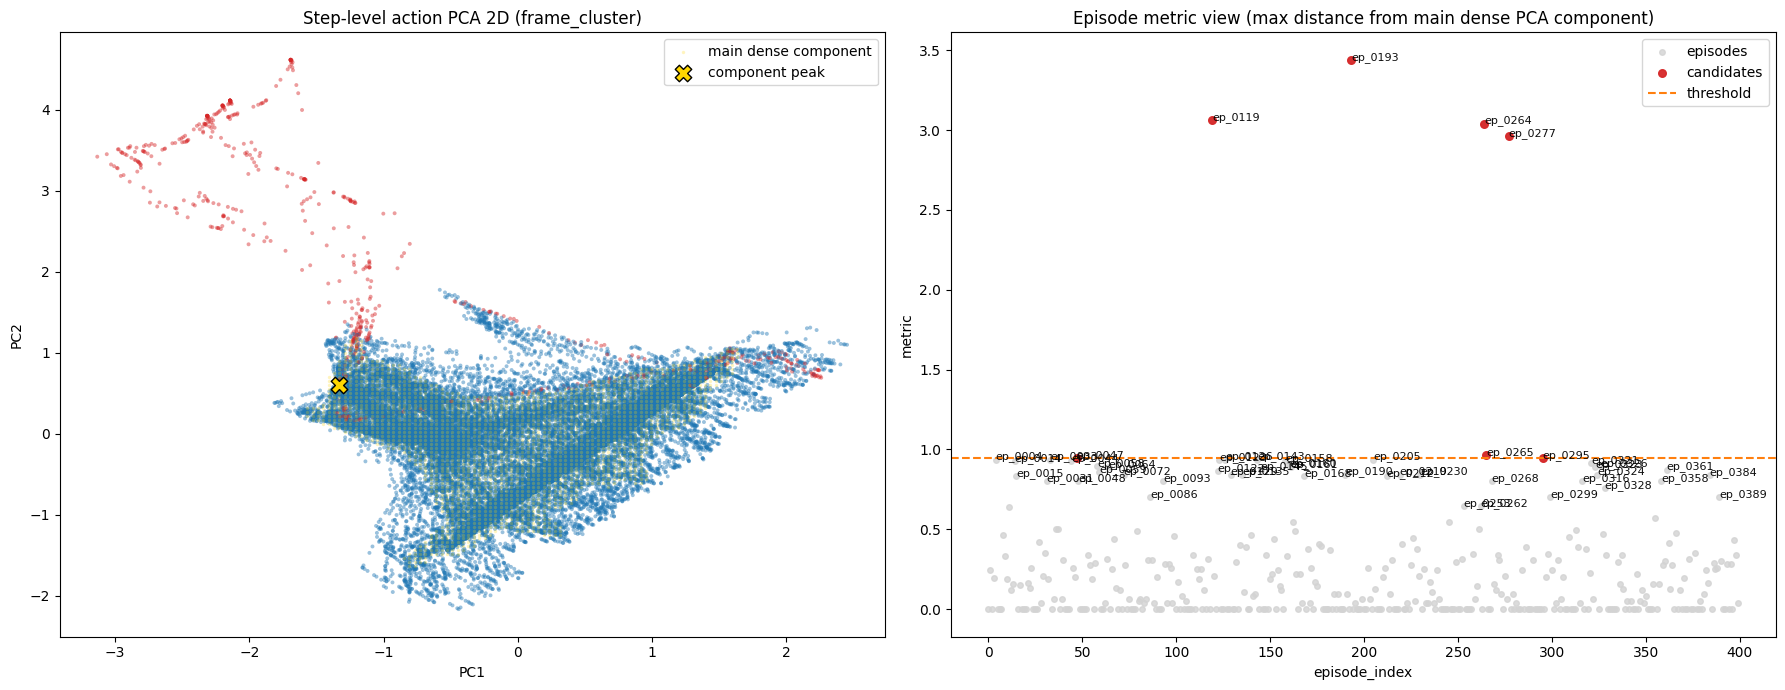

analyzed episodes: 400
analyzed frames: 95650
used action dims: ['joint1', 'joint2', 'joint3', 'joint4', 'joint5', 'joint6', 'rh_r1_joint']
outlier method: frame_cluster
outlier metric: max distance from main dense PCA component
episode threshold (97.5 percentile): 0.945
cluster density percentile: 70
smoothing passes: 2
outside-frame count: 12163

candidate episodes:
[47, 119, 193, 264, 265, 277, 295]

top 50 candidate episodes:
01. episode=0193 | metric=3.440 | length=390 | outside_frames=339
02. episode=0119 | metric=3.061 | length=302 | outside_frames=258
03. episode=0264 | metric=3.041 | length=322 | outside_frames=278
04. episode=0277 | metric=2.962 | length=311 | outside_frames=258
05. episode=0265 | metric=0.963 | length=272 | outside_frames=100
06. episode=0047 | metric=0.945 | length=260 | outside_frames=99
07. episode=0295 | metric=0.945 | length=268 | outside_frames=102
08. episode=0004 | metric=0.937 | length=265 | outside_frames=114
09. episode=0143 | metric=0.937 | lengt

In [24]:
episodes_df = load_all_episode_rows(DATASET_ROOT)
data_df = load_all_data_rows(DATASET_ROOT)
action_names = get_feature_names(DATASET_ROOT, REPO_ID, ACTION_KEY)

action_dim = len(action_names) if MAX_ACTION_DIMS is None else min(MAX_ACTION_DIMS, len(action_names))
action_names = action_names[:action_dim]

step_action_points = np.stack(data_df[ACTION_KEY].map(as_1d_float_array).to_list())[:, :action_dim]
step_episode_indices = data_df['episode_index'].to_numpy(dtype=np.int64)
step_action_embed = pca_2d(step_action_points)

episode_features, episode_indices = build_episode_feature_matrix(episodes_df)
episode_feature_z = robust_zscore(episode_features)

if OUTLIER_METHOD == 'score':
    candidate_episodes, outlier_metric, outlier_threshold, outlier_label, extra = select_outliers_from_episode_score(
        episode_indices=episode_indices,
        episode_feature_z=episode_feature_z,
        percentile=OUTLIER_PERCENTILE,
    )
else:
    candidate_episodes, outlier_metric, outlier_threshold, outlier_label, extra = select_outliers_from_frame_cluster(
        frame_action_embed=step_action_embed,
        frame_episode_indices=step_episode_indices,
        episode_indices=episode_indices,
        percentile=OUTLIER_PERCENTILE,
        bins=MAIN_CLUSTER_BINS,
        density_percentile=CLUSTER_DENSITY_PERCENTILE,
        smoothing_passes=SMOOTHING_PASSES,
    )

outlier_mask = np.isin(episode_indices, candidate_episodes)
ranked_idx = np.argsort(outlier_metric)[::-1]
top_idx = ranked_idx[:TOP_K_OUTLIERS]

rng = np.random.default_rng(RANDOM_SEED)
if len(step_action_embed) > MAX_STEP_POINTS:
    sample_idx = rng.choice(len(step_action_embed), size=MAX_STEP_POINTS, replace=False)
else:
    sample_idx = np.arange(len(step_action_embed))

step_colors = np.where(np.isin(step_episode_indices[sample_idx], candidate_episodes), 'tab:red', 'tab:blue')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(
    step_action_embed[sample_idx, 0],
    step_action_embed[sample_idx, 1],
    s=8,
    c=step_colors,
    alpha=0.45,
    linewidths=0,
)
if OUTLIER_METHOD == 'frame_cluster':
    component = extra['main_component']
    xcenters = extra['xcenters']
    ycenters = extra['ycenters']
    component_points = np.argwhere(component)
    component_xy = np.column_stack([
        xcenters[component_points[:, 0]],
        ycenters[component_points[:, 1]],
    ])
    axes[0].scatter(
        component_xy[:, 0],
        component_xy[:, 1],
        s=6,
        c='gold',
        alpha=0.25,
        linewidths=0,
        label='main dense component',
    )
    peak_center = extra['peak_center']
    axes[0].scatter(
        peak_center[0],
        peak_center[1],
        s=140,
        c='gold',
        edgecolors='black',
        marker='X',
        label='component peak',
    )
axes[0].set_title(f'Step-level {ACTION_KEY} PCA 2D ({OUTLIER_METHOD})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
if OUTLIER_METHOD == 'frame_cluster':
    axes[0].legend(loc='best')

axes[1].scatter(episode_indices, outlier_metric, s=16, c='lightgray', alpha=0.8, label='episodes')
axes[1].scatter(
    episode_indices[outlier_mask],
    outlier_metric[outlier_mask],
    s=30,
    c='tab:red',
    alpha=0.95,
    label='candidates',
)
axes[1].axhline(outlier_threshold, color='tab:orange', linestyle='--', linewidth=1.5, label='threshold')
for idx in top_idx:
    axes[1].annotate(
        f"ep_{episode_indices[idx]:04d}",
        (episode_indices[idx], outlier_metric[idx]),
        fontsize=8,
        alpha=0.95,
    )
axes[1].set_title(f'Episode metric view ({outlier_label})')
axes[1].set_xlabel('episode_index')
axes[1].set_ylabel('metric')
axes[1].legend()
plt.tight_layout()
plt.show()

candidate_episode_list = sorted(int(ep) for ep in candidate_episodes.tolist())
print(f'analyzed episodes: {len(episode_indices)}')
print(f'analyzed frames: {len(step_action_points)}')
print(f'used action dims: {action_names}')
print(f'outlier method: {OUTLIER_METHOD}')
print(f'outlier metric: {outlier_label}')
print(f'episode threshold ({OUTLIER_PERCENTILE} percentile): {outlier_threshold:.3f}')
if OUTLIER_METHOD == 'frame_cluster':
    print(f'cluster density percentile: {CLUSTER_DENSITY_PERCENTILE}')
    print(f'smoothing passes: {SMOOTHING_PASSES}')
    print(f'outside-frame count: {int(extra["frame_is_outside"].sum())}')
print()
print('candidate episodes:')
print(candidate_episode_list)
print()
print(f'top {TOP_K_OUTLIERS} candidate episodes:')
for rank, idx in enumerate(top_idx, start=1):
    outside_count = ''
    if OUTLIER_METHOD == 'frame_cluster':
        outside_count = f" | outside_frames={int(extra['episode_outside_count'][idx])}"
    print(
        f"{rank:02d}. episode={episode_indices[idx]:04d} | metric={outlier_metric[idx]:.3f} | length={int(episodes_df.loc[episodes_df['episode_index'] == episode_indices[idx], 'length'].iloc[0])}{outside_count}"
    )


## rerun viz command
cd ~/ochansol/lerobot

uv run lerobot-dataset-viz \
    --repo-id user1/repo1 \
    --root /nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_aug \
    --mode local \
    --episode-index 0

## Filtering Cell

위 시각화 셀에서 출력된 candidate episode 번호를 보고, 아래 `EPISODES_TO_DELETE`에 직접 넣어서 필터링하면 됩니다.

`WRITE_IN_PLACE = True`면 원본 dataset을 직접 수정합니다. 보통은 먼저 dataset 복사본을 만들어 두고 그 경로를 넣는 편이 안전합니다.


In [25]:
TARGET_DATASET_ROOT = DATASET_ROOT
EPISODES_TO_DELETE = [47, 119, 193, 264, 265, 277, 295]

WRITE_IN_PLACE = True
COPIED_DATASET_ROOT = DATASET_ROOT.parent / f'{DATASET_ROOT.name}_pca_filtered'


def filter_dataset_in_notebook(dataset_root: Path, delete_episode_indices: list[int]) -> None:
    dataset_root = dataset_root.resolve()
    delete_set = sorted(set(int(ep) for ep in delete_episode_indices))

    if not dataset_root.exists():
        raise FileNotFoundError(f'Dataset root does not exist: {dataset_root}')
    if not delete_set:
        raise ValueError('EPISODES_TO_DELETE is empty. Put the selected episode numbers into the list first.')

    info = load_info(dataset_root)
    total_episodes = int(info['total_episodes'])
    invalid = [ep for ep in delete_set if ep < 0 or ep >= total_episodes]
    if invalid:
        raise IndexError(f'Episode indices out of range: {invalid}. Available range: 0..{total_episodes - 1}')
    if len(delete_set) == total_episodes:
        raise ValueError('Deleting all episodes is not supported.')

    backup_file(dataset_root / INFO_PATH)
    backup_file(dataset_root / STATS_PATH)
    backup_file(dataset_root / DEFAULT_TASKS_PATH)

    episodes_backup_root = dataset_root / 'meta' / 'episodes_backup_before_delete'
    if episodes_backup_root.exists():
        shutil.rmtree(episodes_backup_root)
    shutil.copytree(dataset_root / 'meta' / 'episodes', episodes_backup_root)

    keep_episode_map = {}
    next_ep = 0
    for old_ep in range(total_episodes):
        if old_ep in delete_set:
            continue
        keep_episode_map[old_ep] = next_ep
        next_ep += 1

    episodes_df = load_all_episode_rows(dataset_root)
    kept_episodes_df, aggregated_stats, kept_task_names = rewrite_episode_metadata(
        dataset_root,
        episodes_df,
        keep_episode_map,
    )

    old_task_to_new_task = rewrite_tasks(dataset_root, kept_task_names)
    episode_lengths, total_frames = rewrite_data_files(dataset_root, keep_episode_map, old_task_to_new_task)

    if sum(episode_lengths.values()) != total_frames:
        raise RuntimeError('Data parquet rewrite produced inconsistent frame counts.')
    if len(episode_lengths) != len(keep_episode_map):
        raise RuntimeError('Some kept episodes disappeared while rewriting data parquet files.')

    rewrite_info(
        dataset_root,
        total_episodes=len(keep_episode_map),
        total_frames=total_frames,
        total_tasks=len(kept_task_names),
    )
    write_stats(aggregated_stats, dataset_root)

    episodes_dir = dataset_root / 'meta' / 'episodes'
    shutil.rmtree(episodes_dir)
    episodes_dir.mkdir(parents=True, exist_ok=True)
    episode_metadata_path = dataset_root / DEFAULT_EPISODES_PATH.format(chunk_index=0, file_index=0)
    dataframe_to_parquet(kept_episodes_df, episode_metadata_path)

    prune_empty_dirs(dataset_root)

    print(f'Deleted episodes: {delete_set}')
    print(f'Remaining episodes: {len(keep_episode_map)}')
    print(f'Remaining frames: {total_frames}')


if WRITE_IN_PLACE:
    working_root = TARGET_DATASET_ROOT
else:
    working_root = COPIED_DATASET_ROOT
    if working_root.exists():
        raise FileExistsError(f'Output dataset already exists: {working_root}')
    shutil.copytree(TARGET_DATASET_ROOT, working_root)

print(f'Filtering dataset: {working_root}')
filter_dataset_in_notebook(working_root, EPISODES_TO_DELETE)


Filtering dataset: /nas/Dataset/VLA/UON/Isaacsim/OMY_apple_picking/auto_fixed_place_random_light
Deleted episodes: [47, 119, 193, 264, 265, 277, 295]
Remaining episodes: 393
Remaining frames: 93525
